# 📊 Yelp Review Summarizer — Evaluation Notebook

This notebook evaluates the LLM summarization quality using:
1. **Automated metrics**: format compliance, quote faithfulness, theme coverage, hallucination detection
2. **LLM-as-Judge**: Gemini 2.5 Flash scores summaries on faithfulness, completeness, coherence, relevance, and quote accuracy
3. **Model comparison**: Compare Qwen3-0.6B vs 1.7B vs 4B

**Prerequisites**: Run `colab_runner.ipynb` first to build the FAISS index.

---

## 1️⃣ Setup

In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os
REPO_DIR = "/content/NLP-Final--Project"
if os.path.exists(REPO_DIR):
    !cd {REPO_DIR} && git pull
else:
    !git clone https://github.com/chucey/NLP-Final--Project.git {REPO_DIR}
os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already up to date.
Working directory: /content/NLP-Final--Project


In [8]:
!pip install -q \
    langchain \
    langchain-community \
    langchain-core \
    langchain-huggingface \
    langchain-text-splitters \
    faiss-cpu \
    sentence-transformers \
    python-dotenv \
    accelerate \
    google-generativeai

In [9]:
# Load FAISS index from Google Drive (must have been built previously)
DRIVE_INDEX_DIR = "/content/drive/MyDrive/NLP-Project/faiss_yelp"
LOCAL_INDEX_DIR = "faiss_yelp"

if os.path.exists(DRIVE_INDEX_DIR) and os.listdir(DRIVE_INDEX_DIR):
    !cp -r {DRIVE_INDEX_DIR} {LOCAL_INDEX_DIR}
    print("✅ FAISS index loaded from Drive")
elif not os.path.exists(LOCAL_INDEX_DIR):
    print("⚠️ No FAISS index found! Run colab_runner.ipynb first to build it.")
else:
    print("✅ FAISS index already exists locally")

✅ FAISS index loaded from Drive


In [10]:
# =============================================
# 🔑 Configure your Gemini API key here
#    Option 1: Use Colab Secrets (recommended)
#    Option 2: Paste key directly below
# =============================================
try:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
    print("✅ Loaded Gemini API key from Colab Secrets")
except Exception:
    GEMINI_API_KEY = ""  # ← paste your key here if not using Colab Secrets
    if GEMINI_API_KEY:
        print("✅ Using manually configured Gemini API key")
    else:
        print("⚠️ No Gemini API key found. LLM-as-Judge evaluation will be skipped.")

GEMINI_MODEL = GEMINI_MODEL = "gemini-3.1-flash-lite-preview"
# =============================================

✅ Loaded Gemini API key from Colab Secrets


In [11]:
import google.generativeai as genai

genai.configure(api_key=GEMINI_API_KEY)

for m in genai.list_models():
    if "generateContent" in m.supported_generation_methods:
        print(m.name)


models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gem

In [12]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

CUDA available: True
GPU: NVIDIA L4


## 2️⃣ Load Model & Vectorstore

In [13]:
import rag_retrival
from prompt import load_model, summarize_reviews
from evaluate_rag import (
    auto_evaluate,
    llm_judge_evaluate,
    run_full_evaluation,
    evaluate_no_result_handling
)

print("Loading vectorstore...")
vs = rag_retrival.load_vectorstore()
print("✅ Vectorstore loaded!")

Loading vectorstore...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Vectorstore loaded!


In [14]:
MODEL_NAME = "Qwen/Qwen3-4B"
tok, model = load_model(MODEL_NAME)

Loading model: Qwen/Qwen3-4B ...


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Model loaded on CUDA (dtype=torch.bfloat16)


## 3️⃣ Test: No-Result Handling

Verify that the model outputs "No reviews found" when no reviews are provided.

In [15]:
print("Testing no-result handling...")
no_result_test = evaluate_no_result_handling(summarize_reviews, tok, model)
print(f"\n{'✅ ALL PASSED' if no_result_test['all_passed'] else '❌ SOME FAILED'}")

Testing no-result handling...
  ✅ Empty string: No reviews found for the given criteria.
  ✅ Whitespace only: No reviews found for the given criteria.
  ✅ Newlines only: No reviews found for the given criteria.
  ✅ RAG sentinel value: No reviews found for the given criteria.

✅ ALL PASSED


## 4️⃣ Define Test Cases

Each test case uses `metadata_filter` dicts, matching the API of `rag_retrival.retrieve_reviews_for_summary()`.
This includes exact-match filters, substring filters, and range filters (`{"op": "gte", "value": N}`).

In [16]:
import time

# Define test cases with metadata_filter dicts
# These match the signature of rag_retrival.retrieve_reviews_for_summary()
TEST_CASES = [
    {
        "name": "Italian Restaurants (General)",
        "metadata_filter": {"categories": "Italian"},
        "k": 80,
    },
    {
        "name": "Mexican Restaurants",
        "metadata_filter": {"categories": "Mexican"},
        "k": 80,
    },
    {
        "name": "Coffee Shops",
        "metadata_filter": {"categories": "Coffee"},
        "k": 80,
    },
    {
        "name": "1-Star Reviews Only",
        "metadata_filter": {"review_stars": 1},
        "k": 80,
    },
    {
        "name": "5-Star Reviews Only",
        "metadata_filter": {"review_stars": 5},
        "k": 80,
    },
    {
        "name": "High-Rated Italian in Nashville",
        "metadata_filter": {
            "categories": "Italian",
            "city": "Nashville",
            "review_stars": {"op": "gte", "value": 4},
        },
        "k": 80,
    },
    {
        "name": "Low-Rated Breakfast in New Orleans",
        "metadata_filter": {
            "categories": "Breakfast",
            "city": "New Orleans",
            "review_stars": {"op": "lt", "value": 3},
        },
        "k": 80,
    },
    {
        "name": "Sushi in Tampa (All Stars)",
        "metadata_filter": {"categories": "Sushi", "city": "Tampa"},
        "k": 80,
    },
    {
        "name": "No Results (Fake Business)",
        "metadata_filter": {"business_name": "ZZZZZ_NONEXISTENT_BUSINESS_12345"},
        "k": 80,
    },
]

print(f"Defined {len(TEST_CASES)} test cases")
for tc in TEST_CASES:
    print(f"  • {tc['name']}: {tc['metadata_filter']}")

Defined 9 test cases
  • Italian Restaurants (General): {'categories': 'Italian'}
  • Mexican Restaurants: {'categories': 'Mexican'}
  • Coffee Shops: {'categories': 'Coffee'}
  • 1-Star Reviews Only: {'review_stars': 1}
  • 5-Star Reviews Only: {'review_stars': 5}
  • High-Rated Italian in Nashville: {'categories': 'Italian', 'city': 'Nashville', 'review_stars': {'op': 'gte', 'value': 4}}
  • Low-Rated Breakfast in New Orleans: {'categories': 'Breakfast', 'city': 'New Orleans', 'review_stars': {'op': 'lt', 'value': 3}}
  • Sushi in Tampa (All Stars): {'categories': 'Sushi', 'city': 'Tampa'}
  • No Results (Fake Business): {'business_name': 'ZZZZZ_NONEXISTENT_BUSINESS_12345'}


## 5️⃣ Run Evaluation Across All Test Cases

In [17]:
all_results = []

for i, tc in enumerate(TEST_CASES):
    print(f"\n{'='*70}")
    print(f"TEST CASE {i+1}/{len(TEST_CASES)}: {tc['name']}")
    print(f"{'='*70}")

    # Retrieve reviews using metadata_filter dict
    docs = rag_retrival.retrieve_reviews_for_summary(
        vs,
        metadata_filter=tc["metadata_filter"],
        k=tc.get("k", 80),
    )

    doc_len = len(docs) if isinstance(docs, str) else 0
    print(f"Retrieved {doc_len} chars of review data")

    # Generate summary
    print("Generating summary...")
    start_time = time.time()
    summary = summarize_reviews(docs, tok, model)
    gen_time = time.time() - start_time
    print(f"Summary generated in {gen_time:.1f}s ({len(summary)} chars)")
    print(f"\n--- Generated Summary ---\n{summary}\n--- End Summary ---\n")

    # Run evaluation
    eval_result = run_full_evaluation(
        summary, docs,
        api_key=GEMINI_API_KEY if GEMINI_API_KEY else None,
        gemini_model=GEMINI_MODEL
    )

    # ✅ 加这一行，防止 rate limit
    time.sleep(5)  # 15 RPM = 每4秒1次，5秒保险

    all_results.append({
        "test_case": tc["name"],
        "metadata_filter": tc["metadata_filter"],
        "summary": summary,
        "summary_len": len(summary),
        "source_len": doc_len,
        "generation_time": gen_time,
        "evaluation": eval_result,
    })

    # Rate limit buffer for Gemini free tier
    if GEMINI_API_KEY:
        time.sleep(40)

print(f"\n\n✅ All {len(TEST_CASES)} test cases completed!")


TEST CASE 1/9: Italian Restaurants (General)
Retrieved 45177 chars of review data
Generating summary...
Summary generated in 38.1s (2748 chars)

--- Generated Summary ---
## Overall Sentiment  
Positive — the average star rating of 3.5 indicates a mix of positive and neutral feedback across multiple businesses, with notable praise for food quality, service, and ambiance, though some complaints regarding inconsistency, pricing, and service issues are present.

## Top Praised Themes  
- **Food Quality**: Many reviewers highlighted the freshness and taste of the food, particularly at establishments like Brio Italian Grille, Freshco Pizzeria, and Café Roma. For example, “the food was excellent” at Brio Italian Grille, and “wonderful fresh and tasty pizza” was noted at Fresco Pizzeria.  
- **Service Experience**: Positive comments about attentive and friendly staff were common, such as at Anthony’s Coal Fired Pizza where “the food service and decor... the minute we walked in... we were gre

## 6️⃣ Results Summary Table

In [18]:
import pandas as pd

rows = []
for r in all_results:
    auto = r["evaluation"].get("auto", {})
    judge = r["evaluation"].get("judge", {})

    row = {
        "Test Case": r["test_case"],
        "Gen Time (s)": round(r["generation_time"], 1),
        "Summary Len": r["summary_len"],
        "Source Len": r["source_len"],
        "Auto Score": auto.get("overall_auto_score", "N/A"),
        "Format": auto.get("format_compliance", {}).get("score", "N/A"),
        "Quotes": auto.get("quote_faithfulness", {}).get("score", "N/A"),
        "Coverage": auto.get("theme_coverage", {}).get("score", "N/A"),
        "No Halluc.": auto.get("hallucination_check", {}).get("score", "N/A"),
    }

    # Add judge scores if available
    if not judge.get("skipped") and not judge.get("error"):
        row["Judge Score"] = judge.get("overall_judge_score", "N/A")
        for dim in ["faithfulness", "completeness", "coherence", "relevance", "quote_accuracy"]:
            if dim in judge:
                row[f"J-{dim[:5].title()}"] = judge[dim]["score"]
    else:
        row["Judge Score"] = "N/A"

    rows.append(row)

results_df = pd.DataFrame(rows)
print("\n📊 EVALUATION RESULTS SUMMARY")
print("=" * 100)
display(results_df)

# Calculate averages (excluding N/A)
numeric_cols = results_df.select_dtypes(include='number').columns
print("\n📈 AVERAGES:")
for col in numeric_cols:
    valid = results_df[col].dropna()
    if len(valid) > 0:
        print(f"   {col}: {valid.mean():.2f}")


📊 EVALUATION RESULTS SUMMARY


,Test Case,Gen Time (s),Summary Len,Source Len,Auto Score,Format,Quotes,Coverage,No Halluc.,Judge Score,J-Faith,J-Compl,J-Coher,J-Relev,J-Quote
0,Italian Restaurants (General),38.1,2748,45177,0.66,1.0,0.50,0.47,0.75,3.6,2,4,5,4,3
1,Mexican Restaurants,35.4,2759,43438,0.70,1.0,0.50,0.67,0.75,3.2,2,3,5,4,2
2,Coffee Shops,49.0,3663,41815,0.54,1.0,0.00,0.60,0.75,3.6,3,4,5,4,2
3,1-Star Reviews Only,46.7,3295,51842,0.52,1.0,0.13,0.38,0.75,4.0,3,4,5,4,4
4,5-Star Reviews Only,30.7,2239,40172,0.41,1.0,0.25,0.53,0.00,2.6,2,3,5,2,1
5,High-Rated Italian in Nashville,39.9,3047,41640,0.63,1.0,0.50,0.62,0.50,4.8,4,5,5,5,5
6,Low-Rated Breakfast in New Orleans,41.6,2943,48917,0.62,1.0,0.50,0.60,0.50,4.2,3,4,5,5,4
7,Sushi in Tampa (All Stars),35.3,2704,41896,0.70,1.0,0.50,0.41,1.00,3.0,2,3,5,4,1
8,No Results (Fake Business),0.0,40,17,0.34,0.0,0.50,0.00,0.75,4.2,5,5,5,5,1



📈 AVERAGES:
   Gen Time (s): 35.19
   Summary Len: 2604.22
   Source Len: 39434.89
   Auto Score: 0.57
   Format: 0.89
   Quotes: 0.38
   Coverage: 0.48
   No Halluc.: 0.64
   Judge Score: 3.69
   J-Faith: 2.89
   J-Compl: 3.89
   J-Coher: 5.00
   J-Relev: 4.11
   J-Quote: 2.56


## 7️⃣ Visualize Evaluation Results

Plot automated metric scores across test cases (inspired by `evaluate_rag.py` visualization style).

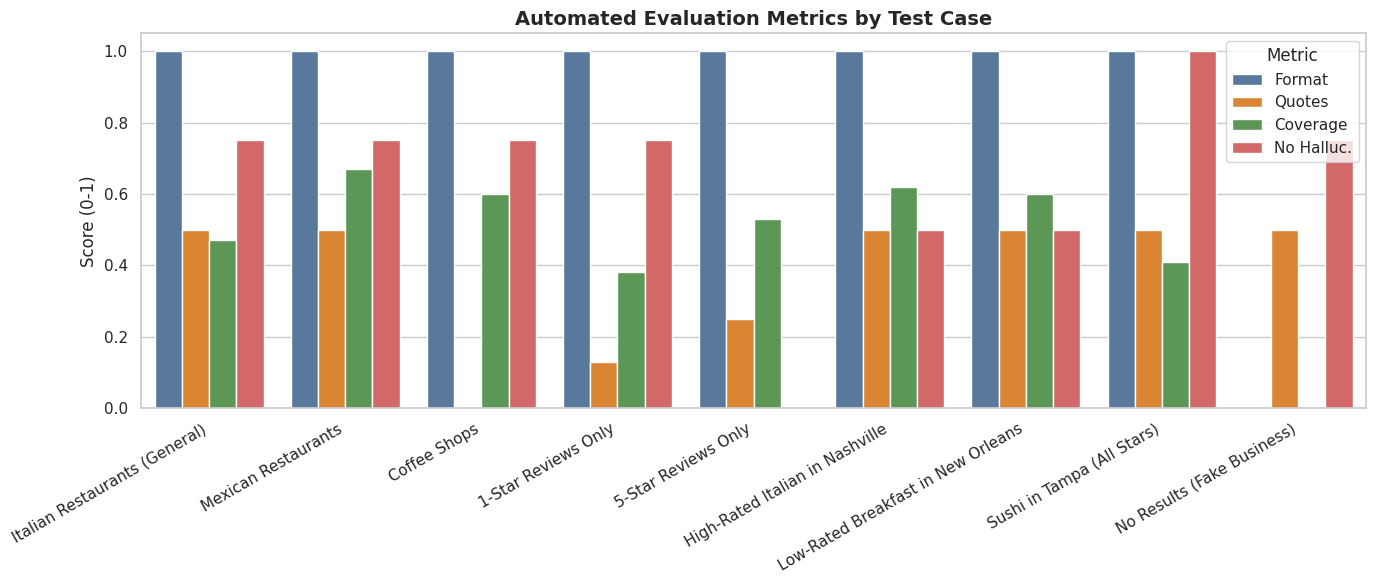

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Build plot dataframe from auto metrics
plot_rows = []
for r in all_results:
    auto = r["evaluation"].get("auto", {})
    if not auto:
        continue
    for metric_key, metric_label in [
        ("format_compliance", "Format"),
        ("quote_faithfulness", "Quotes"),
        ("theme_coverage", "Coverage"),
        ("hallucination_check", "No Halluc."),
    ]:
        score = auto.get(metric_key, {}).get("score")
        if score is not None:
            plot_rows.append({
                "Test Case": r["test_case"],
                "Metric": metric_label,
                "Score": score,
            })

plot_df = pd.DataFrame(plot_rows)

if not plot_df.empty:
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.barplot(
        data=plot_df, x="Test Case", y="Score", hue="Metric",
        palette=["#4C78A8", "#F58518", "#54A24B", "#E45756"],
        ax=ax,
    )
    ax.set_ylim(0, 1.05)
    ax.set_title("Automated Evaluation Metrics by Test Case", fontsize=14, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Score (0-1)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot.")

## 8️⃣ Model Comparison (0.6B vs 1.7B vs 4B)

Compare summarization quality across different Qwen3 model sizes.

> ⚠️ This section loads multiple models sequentially. Each model download may take a few minutes the first time.

In [20]:
import gc

MODELS_TO_COMPARE = [
    "Qwen/Qwen3-0.6B",
    "Qwen/Qwen3-1.7B",
    "Qwen/Qwen3-4B",
]

# Use one consistent test case for fair comparison
COMPARISON_FILTER = {"categories": "Italian"}
COMPARISON_K = 80

print("Retrieving reviews for comparison test...")
comparison_docs = rag_retrival.retrieve_reviews_for_summary(
    vs, metadata_filter=COMPARISON_FILTER, k=COMPARISON_K
)
print(f"Retrieved {len(comparison_docs)} chars of review data")

model_results = []

for model_name in MODELS_TO_COMPARE:
    print(f"\n{'='*60}")
    print(f"🤖 Loading {model_name}...")
    print(f"{'='*60}")

    try:
        tok_cmp, model_cmp = load_model(model_name)

        print("Generating summary...")
        start_time = time.time()
        summary = summarize_reviews(comparison_docs, tok_cmp, model_cmp)
        gen_time = time.time() - start_time
        print(f"Generated in {gen_time:.1f}s ({len(summary)} chars)")
        print(f"\n--- Summary ---\n{summary}\n--- End ---\n")

        # Evaluate
        eval_result = run_full_evaluation(
            summary, comparison_docs,
            api_key=GEMINI_API_KEY if GEMINI_API_KEY else None,
            gemini_model=GEMINI_MODEL
        )

        # ✅ 加这一行，防止 rate limit
        time.sleep(5)  # 15 RPM = 每4秒1次，5秒保险

        model_results.append({
            "model": model_name,
            "summary": summary,
            "summary_len": len(summary),
            "gen_time": gen_time,
            "evaluation": eval_result,
        })

        # Free GPU memory before loading next model
        del model_cmp, tok_cmp
        gc.collect()
        torch.cuda.empty_cache()

        if GEMINI_API_KEY:
            time.sleep(40)  # Rate limit buffer

    except Exception as e:
        print(f"❌ Failed to load {model_name}: {e}")
        model_results.append({
            "model": model_name,
            "error": str(e),
        })

print(f"\n✅ Model comparison complete!")

Retrieving reviews for comparison test...
Retrieved 45177 chars of review data

🤖 Loading Qwen/Qwen3-0.6B...
Loading model: Qwen/Qwen3-0.6B ...


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Model loaded on CUDA (dtype=torch.bfloat16)
Generating summary...
Generated in 15.6s (1423 chars)

--- Summary ---
## Overall Sentiment
mixed — There are positive aspects across multiple reviews, particularly highlighting exceptional food, attentive service, and unique offerings. However, there are notable complaints regarding inconsistent quality, poor service, and pricing issues.

## Top Praised Theme
- **Brio Italian Grille**: Excellent food, outstanding service, and a welcoming environment. Reviewed by 3 patrons with 5-star ratings.  
- **Angelina's**: Exceptionally flavorful and authentic Italian cuisine, praised for its warmth and authenticity. Rated 5 stars.  
- **Fresco Pizzeria**: Known for fresh, tasty pizza and a clean, inviting atmosphere. Rated 5 stars.  

## Top Complaints
- **Casselli's Ristorante**: Poor service, unpleasant dining experience, and inconsistent food quality. Rated 1 star.  
- **Lazos Pizza & Grill**: Overwhelmingly greasy and greasy-tasting food, with poo

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Model loaded on CUDA (dtype=torch.bfloat16)
Generating summary...
Generated in 28.4s (1995 chars)

--- Summary ---
## Overall Sentiment  
Positive — the average star rating of 3.5 indicates a mix of positive and neutral feedback across multiple establishments, with notable praise for food quality, service, and ambiance.

## Top Praised Themes  
- **Food Quality**: Multiple reviews highlight exceptional food preparation, freshness, and variety. For example, "the food was excellent, nothing to change there" (Convivio Italian Artisan Cuisine, 5 stars) and "the food was well prepared and fresh" (Porcini, 3 stars).  
- **Service Experience**: Many reviewers praised attentive and friendly service. A standout mention is "the staff was super nice and will accommodate to whatever your needs may be" (Fellini Cafe of Media, 5 stars).  
- **Ambiance and Atmosphere**: Several businesses were noted for their welcoming environments. "The interior is quaint and the lighting is dim—it’s a nice place fo

In [21]:
# Build comparison table
comp_rows = []
for r in model_results:
    if "error" in r:
        comp_rows.append({"Model": r["model"], "Error": r["error"]})
        continue

    auto = r["evaluation"].get("auto", {})
    judge = r["evaluation"].get("judge", {})

    row = {
        "Model": r["model"].split("/")[-1],
        "Gen Time (s)": round(r["gen_time"], 1),
        "Summary Len": r.get("summary_len", "N/A"),
        "Auto Score": auto.get("overall_auto_score", "N/A"),
        "Format": auto.get("format_compliance", {}).get("score", "N/A"),
        "Quotes": auto.get("quote_faithfulness", {}).get("score", "N/A"),
        "Coverage": auto.get("theme_coverage", {}).get("score", "N/A"),
        "No Halluc.": auto.get("hallucination_check", {}).get("score", "N/A"),
    }

    if not judge.get("skipped") and not judge.get("error"):
        row["Judge Score"] = judge.get("overall_judge_score", "N/A")
        for dim in ["faithfulness", "completeness", "coherence", "relevance", "quote_accuracy"]:
            if dim in judge:
                row[f"J-{dim[:5].title()}"] = judge[dim]["score"]

    comp_rows.append(row)

comp_df = pd.DataFrame(comp_rows)
print("\n📊 MODEL COMPARISON RESULTS")
print("=" * 100)
print(f"Test case: {COMPARISON_FILTER}")
display(comp_df)


📊 MODEL COMPARISON RESULTS
Test case: {'categories': 'Italian'}


,Model,Gen Time (s),Summary Len,Auto Score,Format,Quotes,Coverage,No Halluc.,Judge Score,J-Faith,J-Compl,J-Coher,J-Relev,J-Quote
0,Qwen3-0.6B,13.0,1302,0.35,1.0,0.00,0.35,0.25,3.0,2,2,4,3,4
1,Qwen3-1.7B,15.6,1423,0.54,1.0,0.00,0.35,1.00,3.0,2,3,5,4,1
2,Qwen3-4B,28.4,1995,0.71,1.0,0.57,0.35,1.00,4.0,3,4,5,5,3


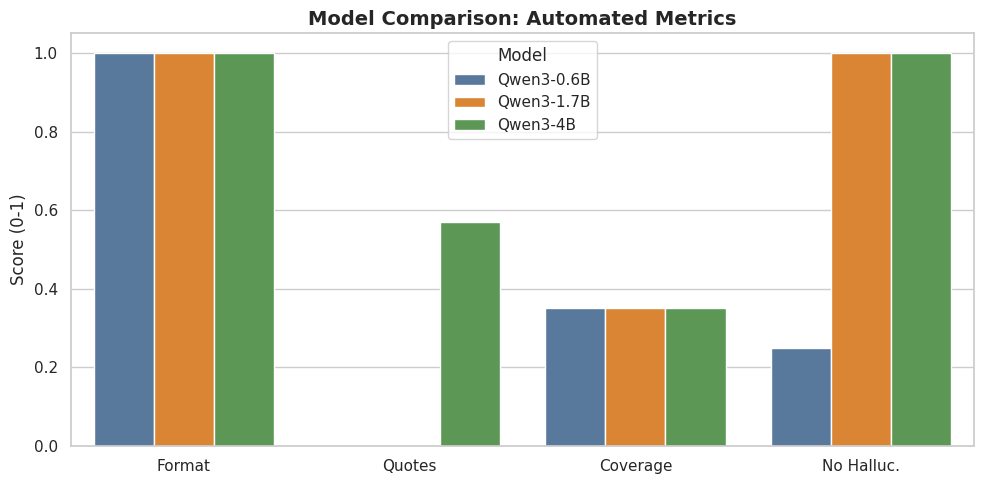

In [22]:
# Visualize model comparison (bar chart inspired by evaluate_rag.py)
comp_plot_rows = []
for r in model_results:
    if "error" in r:
        continue
    auto = r["evaluation"].get("auto", {})
    model_short = r["model"].split("/")[-1]
    for metric_key, metric_label in [
        ("format_compliance", "Format"),
        ("quote_faithfulness", "Quotes"),
        ("theme_coverage", "Coverage"),
        ("hallucination_check", "No Halluc."),
    ]:
        score = auto.get(metric_key, {}).get("score")
        if score is not None:
            comp_plot_rows.append({
                "Model": model_short,
                "Metric": metric_label,
                "Score": score,
            })

comp_plot_df = pd.DataFrame(comp_plot_rows)

if not comp_plot_df.empty:
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(
        data=comp_plot_df, x="Metric", y="Score", hue="Model",
        palette=["#4C78A8", "#F58518", "#54A24B"],
        ax=ax,
    )
    ax.set_ylim(0, 1.05)
    ax.set_title("Model Comparison: Automated Metrics", fontsize=14, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Score (0-1)")
    plt.tight_layout()
    plt.show()
else:
    print("No comparison data to plot.")

## 9️⃣ Save Results

In [23]:
import json

# Save results to Google Drive
save_dir = "/content/drive/MyDrive/NLP-Project/eval_results"
os.makedirs(save_dir, exist_ok=True)

# Save test case results
results_df.to_csv(f"{save_dir}/test_case_results.csv", index=False)

# Save model comparison results
if 'comp_df' in dir():
    comp_df.to_csv(f"{save_dir}/model_comparison_results.csv", index=False)

# Save detailed results as JSON
serializable_results = []
for r in all_results:
    sr = {k: v for k, v in r.items()}
    serializable_results.append(sr)

with open(f"{save_dir}/detailed_results.json", "w") as f:
    json.dump(serializable_results, f, indent=2, default=str)

print(f"✅ Results saved to {save_dir}/")
print(f"   • test_case_results.csv")
print(f"   • model_comparison_results.csv")
print(f"   • detailed_results.json")

✅ Results saved to /content/drive/MyDrive/NLP-Project/eval_results/
   • test_case_results.csv
   • model_comparison_results.csv
   • detailed_results.json
